In [2]:
import os

print(os.getcwd())

c:\Users\Mokutmfon Williams\Desktop\Projects\mlops


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f"Shape: {df.shape}")
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [5]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [6]:
# Check what's going wrong with TotalCharges
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][
    ["customerID", "tenure", "TotalCharges"]
]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [7]:
# Convert TotalCharges to numeric, coercing bad values to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Since these are all tenure==0 customers, it makes sense to fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Confirm the fix
df["TotalCharges"].dtype

dtype('float64')

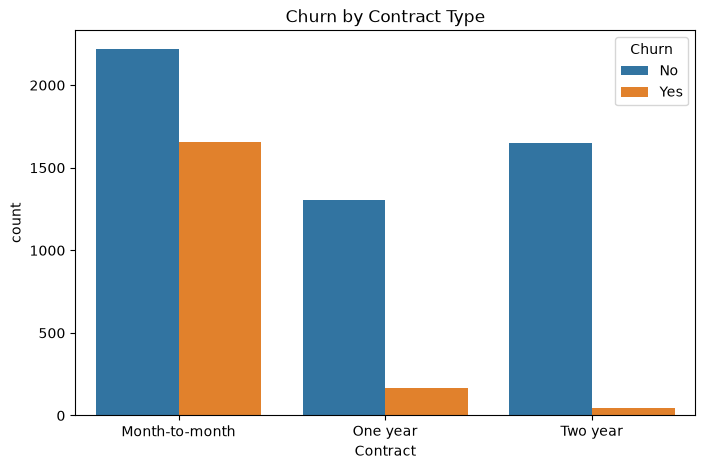

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

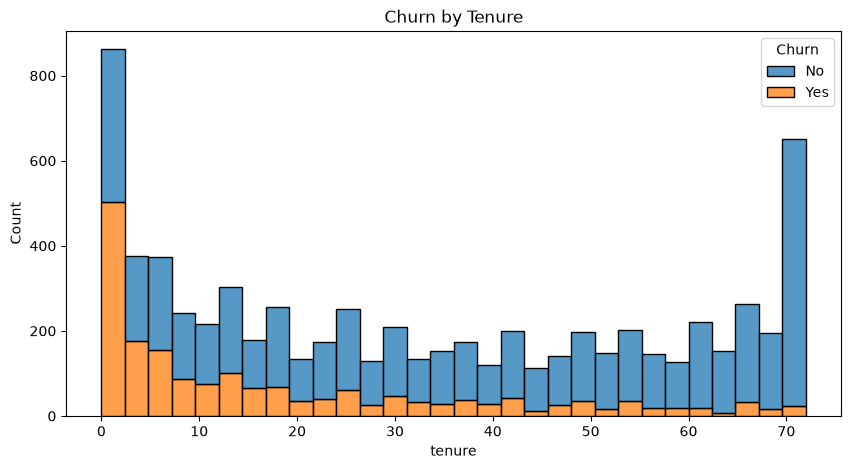

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Churn by Tenure")
plt.show()

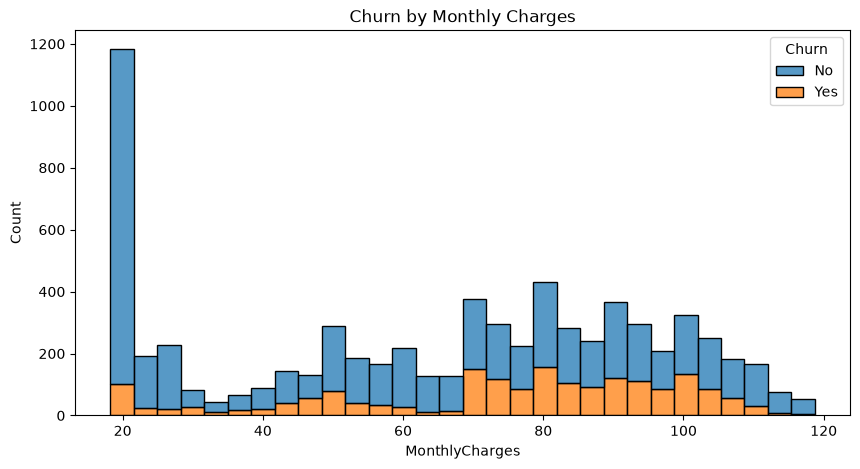

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", bins=30)
plt.title("Churn by Monthly Charges")
plt.show()

In [11]:
# Drop customerID - it's just an identifier, not a predictive feature
df_model = df.drop("customerID", axis=1)

# Check which columns are categorical (object/str type)
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\Mokutmfon Williams\AppData\Local\Temp\ipykernel_4528\3236338265.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include='object').columns.tolist()


In [12]:
# Binary encoding for Yes/No and gender columns
binary_map = {"Yes": 1, "No": 0}
df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})
df_model["Partner"] = df_model["Partner"].map(binary_map)
df_model["Dependents"] = df_model["Dependents"].map(binary_map)
df_model["PhoneService"] = df_model["PhoneService"].map(binary_map)
df_model["PaperlessBilling"] = df_model["PaperlessBilling"].map(binary_map)
df_model["Churn"] = df_model["Churn"].map(binary_map)

# One-hot encode remaining multi-category columns
multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(f"Final shape: {df_model.shape}")
df_model.head()

Final shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [13]:
df_model.to_csv("data/churn_processed.csv", index=False)
print("Saved processed dataset")

Saved processed dataset


In [14]:
import joblib
import pandas as pd

model = joblib.load("models/churn_model.pkl")
scaler = joblib.load("models/scaler.pkl")
feature_columns = joblib.load("models/feature_columns.pkl")

test_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.5,
    "TotalCharges": 171.0,
}

test_df = pd.DataFrame([test_customer])
binary_map = {"Yes": 1, "No": 0}
test_df["gender"] = test_df["gender"].map({"Male": 1, "Female": 0})
test_df["Partner"] = test_df["Partner"].map(binary_map)
test_df["Dependents"] = test_df["Dependents"].map(binary_map)
test_df["PhoneService"] = test_df["PhoneService"].map(binary_map)
test_df["PaperlessBilling"] = test_df["PaperlessBilling"].map(binary_map)

multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]
test_df = pd.get_dummies(test_df, columns=multi_cat_cols, drop_first=True)
test_df = test_df.reindex(columns=feature_columns, fill_value=0)

scaled = scaler.transform(test_df)
print("Prediction:", model.predict(scaled))
print("Probability:", model.predict_proba(scaled))

Prediction: [0]
Probability: [[0.83126372 0.16873628]]
